<h1> Import

In [1]:

from masterthesis.data.loaders import load_module_dataframe
from masterthesis.data.datasets import subsampled_env_dict
from masterthesis.data.preprocessing import preprocess_env_data
from masterthesis.data.dataset_object import make_environment_dataset, make_observational_dataset

from masterthesis.algorithms.notears import run_notears
from masterthesis.algorithms.pc import run_pc
from masterthesis.algorithms.dotears import run_dotears, run_dotears_test, run_dotears_test2

from masterthesis.experiments import run_algorithms
from masterthesis.evaluation import load_all_dags, dag_frequency_matrix
from masterthesis.visualization import plot_dag_frequency_heatmap, save_graph_plot

import numpy as np


<h1> Modular-level Experiments

<h2> Data

In [2]:
modular_df = load_module_dataframe()

# keep dynamic regimes
#cell_df = cell_df[cell_df["StepIndex"].isin([9, 17,18,19,20,21])]

# downsample

modular_df.head()


,Cell,aged,Resistance,Temp,CurrentA,TestTimes,StepTimes,CycleIndex,StepIndex,VoltageV,TemperatureC_Cell_1,TemperatureC_Cell_2,TemperatureC_Cell_3,TemperatureC_Cell_4,Ambient_TemperatureC,CurrentA_Cell_1,CurrentA_Cell_2,CurrentA_Cell_3,CurrentA_Cell_4
0,Mixed,Aged,0,10,0.0,1.0003,1.0002,1,1,3.572477,19.970938,20.079184,20.310024,20.374929,19.451006,0.345851,-0.278137,0.484834,-0.211766
1,Mixed,Aged,0,10,0.0,2.0003,2.0002,1,1,3.572603,19.970938,20.079184,20.310024,20.374929,19.451006,0.342995,-0.277506,0.487216,-0.201899
2,Mixed,Aged,0,10,0.0,3.0002,3.0001,1,1,3.572414,20.016722,20.002285,20.341354,20.276442,19.561859,0.297878,-0.323768,0.440858,-0.276420
3,Mixed,Aged,0,10,0.0,4.0001,4.0000,1,1,3.571972,19.815464,20.053652,20.234016,20.356627,19.490467,0.298016,-0.326851,0.432864,-0.285413
4,Mixed,Aged,0,10,0.0,5.0003,5.0002,1,1,3.572288,19.790602,20.113615,20.214621,20.438178,19.492714,0.346711,-0.281970,0.489479,-0.207747


In [3]:
groups = [[1, 4, 6], [2, 7], [3, 8], [5]]
cols = ['CurrentA', 'Ambient_TemperatureC', 'VoltageV', 'CycleIndex', 
        'TemperatureC_Cell_1', 'TemperatureC_Cell_2', 'TemperatureC_Cell_3', 'TemperatureC_Cell_4',
        'CurrentA_Cell_1', 'CurrentA_Cell_2', 'CurrentA_Cell_3','CurrentA_Cell_4']

env_df = subsampled_env_dict(modular_df, cols, groups, sort_by="StepIndex", max_samples_per_env=200000, seed=42)


Group
0    977525
1    851616
2    324326
3    249502
Name: count, dtype: int64


<h3> Preprocessing (scaling+noise)

In [4]:
env_data = preprocess_env_data(
    env_df,
    scale=True,
    noise_std=0.00000000001,
    seed=42,
)

print(env_data.keys())

dict_keys([np.int64(0), np.int64(1), np.int64(2), np.int64(3)])
after scale: [2.82662782e-13 1.00809536e+00 7.66269547e-01 0.00000000e+00
 1.01020855e+00 1.01108193e+00 1.00886601e+00 1.00790796e+00
 5.24117890e-02 8.50237093e-02 6.11459365e-02 8.28198119e-02]
after noise: [1.00000040e-11 1.00809536e+00 7.66269547e-01 1.00106409e-11
 1.01020855e+00 1.01108193e+00 1.00886601e+00 1.00790796e+00
 5.24117890e-02 8.50237093e-02 6.11459365e-02 8.28198119e-02]
dict_keys([np.int64(0), np.int64(1), np.int64(2), np.int64(3)])


<h3> Dataset

In [5]:
interventions = {
    0: [],     # rest = observational
    1: [0],    # 
    2: [0],    # 
    3: [0],    # 
}
dataset = make_environment_dataset(env_data, interventions)

X_obs = np.vstack(list(env_data.values()))
dataset_obs = make_observational_dataset(X_obs)


In [6]:
print(dataset["X"].shape)
print(dataset["X"][:10])
print(dataset["X"].std(axis=0))     


(800000, 12)
[[ 1.52465037e-01 -7.72758514e-02 -7.25485584e-01  1.52302986e-11
  -8.65533005e-02 -1.21070141e-01 -1.01761861e-01 -1.22899037e-01
   1.68827138e-01  1.64371598e-01  1.60862605e-01  1.32063379e-01]
 [ 1.52465037e-01 -6.02419898e-02 -1.77154740e+00 -5.62287529e-12
  -6.27833169e-02 -8.93725621e-02 -6.32200561e-02 -9.02647987e-02
   1.68633040e-01  1.53325270e-01  1.49408518e-01  1.36255812e-01]
 [ 1.52465037e-01 -1.18461756e+00 -7.33446995e-01  3.75698018e-12
  -1.27706437e+00 -1.26228210e+00 -1.25059318e+00 -1.23606764e+00
   1.60558732e-01  1.52123043e-01  1.35095023e-01  1.13027642e-01]
 [ 1.52465037e-01 -1.19741895e+00 -6.68729085e-01  1.96861236e-12
  -1.30449989e+00 -1.29295938e+00 -1.27696991e+00 -1.25877124e+00
   1.69908208e-01  1.61310965e-01  1.40040134e-01  1.41929713e-01]
 [ 1.52465037e-01 -4.90838564e-02 -6.13816300e-01 -3.85082280e-12
  -6.94225156e-02 -1.01422371e-01 -8.18273383e-02 -1.03527638e-01
   1.64947555e-01  1.62084975e-01  1.50414765e-01  1.518661

In [7]:
import pandas as pd

pd.DataFrame(dataset["X"], columns=cols).corr()

,CurrentA,Ambient_TemperatureC,VoltageV,CycleIndex,TemperatureC_Cell_1,TemperatureC_Cell_2,TemperatureC_Cell_3,TemperatureC_Cell_4,CurrentA_Cell_1,CurrentA_Cell_2,CurrentA_Cell_3,CurrentA_Cell_4
CurrentA,1.000000,-0.032771,0.520619,0.001667,-0.082567,-0.078270,-0.076539,-0.072801,0.986235,0.994938,0.994202,0.990287
Ambient_TemperatureC,-0.032771,1.000000,-0.066545,-0.000899,0.996358,0.996726,0.996948,0.997305,-0.038386,-0.039092,-0.040592,-0.039447
VoltageV,0.520619,-0.066545,1.000000,0.000700,-0.098226,-0.098990,-0.100357,-0.098594,0.461352,0.512562,0.540729,0.559718
CycleIndex,0.001667,-0.000899,0.000700,1.000000,-0.001026,-0.000997,-0.001009,-0.000954,0.001748,0.001757,0.001732,0.001711
TemperatureC_Cell_1,-0.082567,0.996358,-0.098226,-0.001026,1.000000,0.999532,0.999233,0.998846,-0.086912,-0.089530,-0.091903,-0.090872
TemperatureC_Cell_2,-0.078270,0.996726,-0.098990,-0.000997,0.999532,1.000000,0.999561,0.999460,-0.081208,-0.085196,-0.088174,-0.087475
TemperatureC_Cell_3,-0.076539,0.996948,-0.100357,-0.001009,0.999233,0.999561,1.000000,0.999591,-0.078446,-0.082725,-0.086622,-0.086265
TemperatureC_Cell_4,-0.072801,0.997305,-0.098594,-0.000954,0.998846,0.999460,0.999591,1.000000,-0.074526,-0.078566,-0.082531,-0.082809
CurrentA_Cell_1,0.986235,-0.038386,0.461352,0.001748,-0.086912,-0.081208,-0.078446,-0.074526,1.000000,0.989298,0.977018,0.966711
CurrentA_Cell_2,0.994938,-0.039092,0.512562,0.001757,-0.089530,-0.085196,-0.082725,-0.078566,0.989298,1.000000,0.992710,0.986701


In [8]:
for k,v in env_data.items():
    print(k, v.shape)

0 (200000, 12)
1 (200000, 12)
2 (200000, 12)
3 (200000, 12)


In [9]:
print(dataset['envs'])

{np.int64(0): array([[ 0.15246504, -0.07727585, -0.72548558, ...,  0.1643716 ,
         0.16086261,  0.13206338],
       [ 0.15246504, -0.06024199, -1.7715474 , ...,  0.15332527,
         0.14940852,  0.13625581],
       [ 0.15246504, -1.18461756, -0.733447  , ...,  0.15212304,
         0.13509502,  0.11302764],
       ...,
       [ 0.15246504, -1.16808857, -1.6854225 , ...,  0.14914089,
         0.15363364,  0.13456498],
       [ 0.15246504, -0.06104015, -0.26147765, ...,  0.17558418,
         0.16762124,  0.07376608],
       [ 0.15246504, -1.2598979 , -0.70259583, ...,  0.15178484,
         0.1554183 ,  0.16084667]]), np.int64(1): array([[ 0.95478159, -0.02434242, -0.02375156, ...,  0.98060816,
         0.9345264 ,  0.8965189 ],
       [ 0.95479579, -0.00638833, -0.29025332, ...,  0.94511735,
         0.94425296,  0.90235044],
       [ 0.95487175, -1.20939785,  0.08154167, ...,  0.93397426,
         0.96226813,  0.88207784],
       ...,
       [ 0.95488559, -0.04663603,  0.96933699, 

<h2> PC

In [10]:
dag_pc = run_pc(dataset)
print(dag_pc)

  0%|          | 0/12 [00:00<?, ?it/s]

[[0 0 1 0 1 0 0 1 1 1 1 1]
 [0 0 1 0 1 1 1 1 0 0 0 0]
 [1 1 0 0 1 0 0 0 1 1 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [1 1 1 0 0 1 1 0 1 0 0 1]
 [0 1 0 0 1 0 1 1 0 0 0 0]
 [0 1 0 0 1 1 0 1 0 0 1 0]
 [1 1 0 0 0 1 1 0 1 0 0 0]
 [1 0 1 0 1 0 0 1 0 1 1 1]
 [1 0 1 0 0 0 0 0 1 0 1 1]
 [1 0 0 0 0 0 1 0 1 1 0 1]
 [1 0 1 0 1 0 0 0 1 1 1 0]]


<h2> No-Tears

In [11]:
dag_notears = run_notears(dataset_obs)
print(dag_notears)

100%|██████████| 20/20 [00:15<00:00,  1.30it/s]

[[0 0 0 0 0 0 0 0 0 1 0 0]
 [1 0 0 0 0 1 0 0 1 1 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 1 1 1 1]
 [0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0 1 0]
 [0 0 0 0 1 0 0 0 0 0 1 1]
 [0 0 1 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 1 0 0 0 0 0 0 0 0 0]]


<h2> Third alg-Do Tears

In [33]:
dag_dotears = run_dotears_test(dataset, lambda1=0.02, w_threshold=0.15)
print(dag_dotears)

[[0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 1 1]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 1 1 1 0 0 0 0]
 [0 1 0 0 0 0 1 1 0 0 0 0]
 [0 1 0 0 0 0 0 1 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 1 0 0 0]
 [1 0 0 0 0 0 0 0 1 1 0 0]
 [1 0 0 0 0 0 0 0 1 1 1 0]]


In [ ]:
dag_dotears2 = run_dotears_test2(dataset, lambda1=0.02, w_threshold=0.2)
print(dag_dotears2)

/Users/christofferslettebo/anaconda3/envs/Master/lib/python3.10/site-packages/scipy/linalg/_matfuncs.py:373: RuntimeWarning: overflow encountered in matmul
  eAw = eAw @ eAw
/Users/christofferslettebo/Desktop/MASTER THESIS/Master-Thesis/Master-Thesis/Src/masterthesis/algorithms/test_tears.py:311: RuntimeWarning: invalid value encountered in multiply
  G = E.T * W * 2


[[0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 1 1 1 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 1 1 1 0 0 0 0]
 [0 1 0 0 1 0 1 1 0 0 0 0]
 [0 1 0 0 1 1 0 1 0 0 0 0]
 [0 1 0 0 1 1 1 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 1 1 1]
 [1 0 0 0 0 0 0 0 1 0 1 1]
 [1 0 0 0 0 0 0 0 1 1 0 1]
 [1 0 0 0 0 0 0 0 1 1 1 0]]


<h2> Third alg- GIES

<h2> Compare/Results?

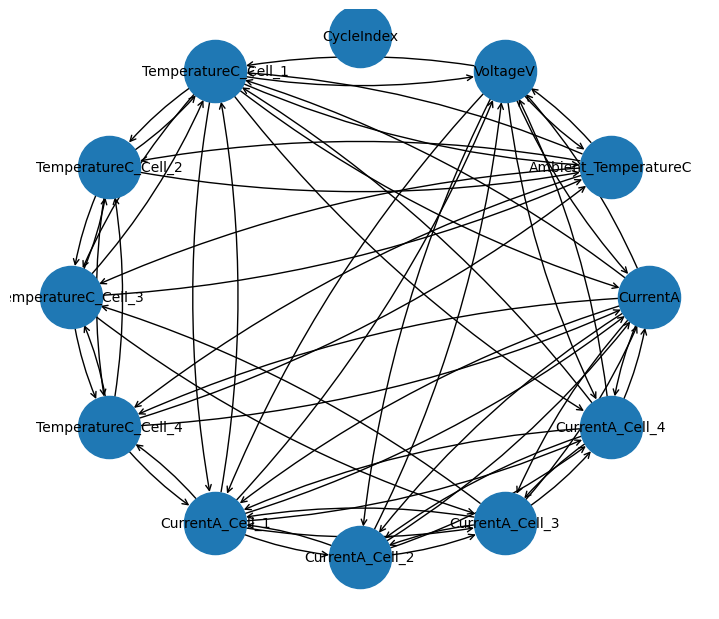

In [14]:
save_graph_plot(cols, dag_pc) 

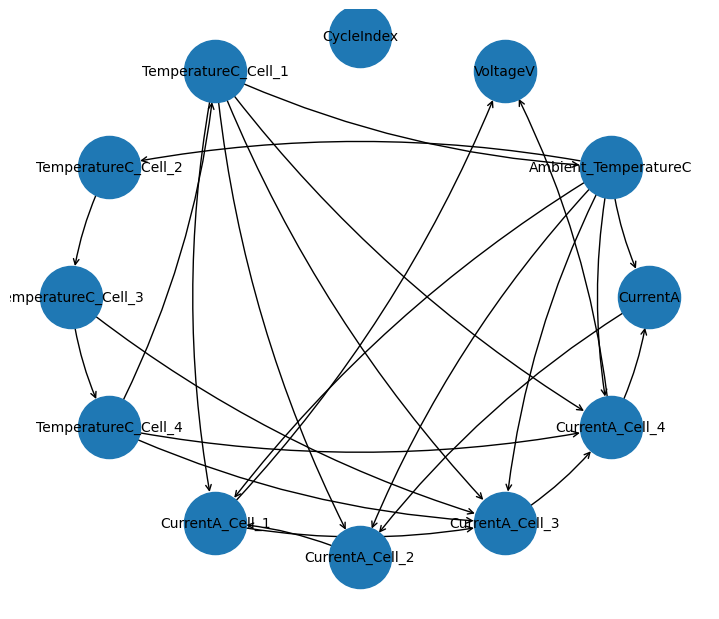

In [27]:
save_graph_plot(cols, dag_notears) 

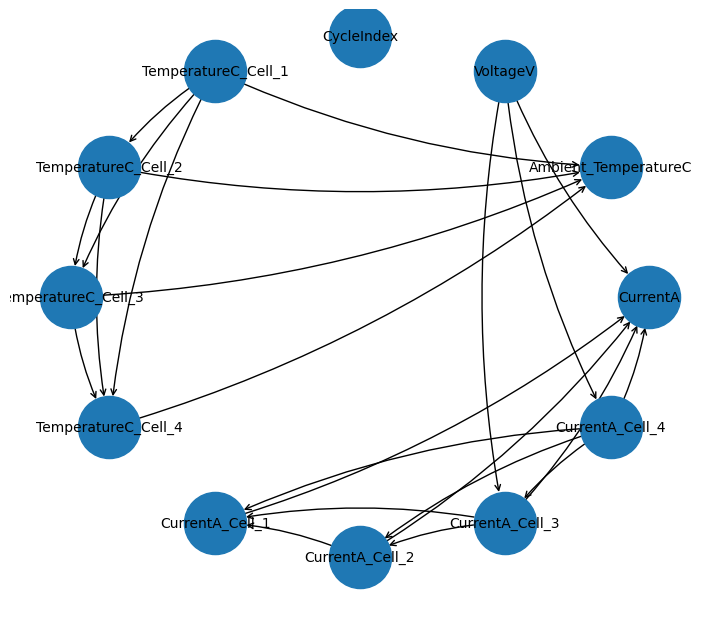

In [34]:
save_graph_plot(cols, dag_dotears) 

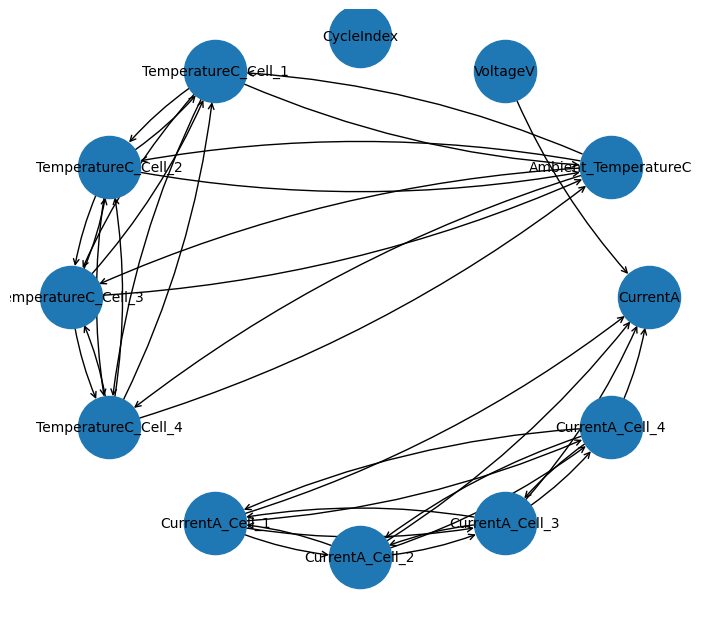

In [31]:
save_graph_plot(cols, dag_dotears2) 